# Loading a Dataset

In [ ]:
!wget https://pjreddie.com/media/files/mnist_test.csv

--2023-04-18 13:20:38--  https://pjreddie.com/media/files/mnist_test.csv
Resolving pjreddie.com (pjreddie.com)... 128.208.4.108
Connecting to pjreddie.com (pjreddie.com)|128.208.4.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18289443 (17M) [application/octet-stream]
Saving to: ‘mnist_test.csv’

mnist_test.csv      100%[===================>]  17.44M  24.0MB/s    in 0.7s    

2023-04-18 13:20:39 (24.0 MB/s) - ‘mnist_test.csv’ saved [18289443/18289443]



# Import Required Library

In [ ]:
from torch import nn
import torch
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load Dataset

In [ ]:
data =

In [ ]:
x = data[:, 1:]
y = data[:, 0]

In [ ]:
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.int64)

In [ ]:
print(x.shape, y.shape)

torch.Size([10000, 784]) torch.Size([10000])


# Train and Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
  x, y, test_size=0.33, random_state=42)

# MODEL

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_features=input, out_features=64)
        self.fc2 = torch.nn.Linear(in_features=64, out_features=64)
        self.fc3 = torch.nn.Linear(in_features=64, out_features=output)
        self.relu = torch.nn.ReLU()
        self.softmax =torch.nn.Softmax(dim=1)
        # Activation function

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        out = self.softmax(self.fc3(x))
        return out

# Create Model

In [ ]:
model = Net(input=784,output=10)

In [ ]:
criterion = nn.CrossEntropyLoss()
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(),lr=lr)

In [ ]:
def accuracy(y_pred, y):
  """
  Calculate accuracy
  """
  # CODE

In [ ]:
history = {'loss':[], 'loss_val':[], 'accuracy':[], 'val_accuracy':[]}

In [ ]:
epochs =450
for epoch in range(epochs):


    # Clear gradient buffers because we don't want any gradient from previous epoch to carry forward, dont want to cummulate gradients
    optimizer.zero_grad()

    # get output from the model, given the inputs
    y_hat = model(x_train)

    # get loss for the predicted output
    loss = criterion(y_hat, y_train)
    loss_val = criterion(model(x_test), y_test)
    # get gradients w.r.t to parameters
    loss.backward()

    # update parameters
    optimizer.step()

    # pred_label_train = torch.argmax(y_hat,dim=1)
    # accuracy = f1_score(y_train, pred_label_train,average='macro')
    acc = accuracy(y_hat,y_train)
    val_acc = accuracy(model(x_test), y_test)

    history['loss'].append(loss.item())
    history['loss_val'].append(loss_val.item())
    history['accuracy'].append(acc.item())
    history['val_accuracy'].append(val_acc.item())

    if epoch%10==0:

      print(f'epoch {epoch}, loss {loss.item():.3f} Accuracy {acc:.2f}  Validation Accuracy: {val_acc:.2f}')

In [ ]:
pred = model(x_test[:100])

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

In [ ]:
pred = # find label id

In [ ]:
cm = # calculate confusion matrix

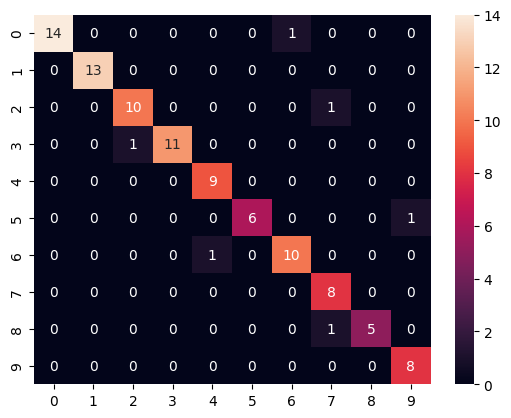

In [ ]:
import seaborn as sns
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
#loss_graph